In [26]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# --- Model parameters ---
S0     = 100.0      # initial mid-price
sigma  = 2.0         # volatility of mid-price
T      = 5.0         # trading horizon (e.g. 1 trading day, normalized)
gamma  = 0.01         # risk aversion
k      = 1.5         # order book liquidity decay parameter
A      = 140.0       # base order arrival intensity

# --- Simulation parameters ---
n_steps = 200         # time steps
dt      = T / n_steps
n_paths = 1            # start with a single path for visualization

In [27]:
def simulate_market_maker(S0, sigma, T, gamma, k, A, n_steps, seed=None):
    """
    Simulates the Avellaneda-Stoikov market making strategy over one path.
    Returns time series of mid-price, quotes, inventory, cash, and wealth.
    """
    if seed is not None:
        np.random.seed(seed)

    dt = T / n_steps
    times = np.linspace(0, T, n_steps + 1)

    S = np.zeros(n_steps + 1)
    q = np.zeros(n_steps + 1)          # inventory
    x = np.zeros(n_steps + 1)          # cash
    bid = np.zeros(n_steps + 1)
    ask = np.zeros(n_steps + 1)
    reservation = np.zeros(n_steps + 1)

    S[0] = S0

    for i in range(n_steps):
        t = times[i]
        time_left = T - t

        # --- Reservation price (inventory-adjusted mid) ---
        r = S[i] - q[i] * gamma * sigma**2 * time_left
        reservation[i] = r

        # --- Optimal total spread ---
        spread = gamma * sigma**2 * time_left + (2 / gamma) * np.log(1 + gamma / k)

        bid[i] = r - spread / 2
        ask[i] = r + spread / 2

        # Distance of each quote from the current mid-price
        delta_b = S[i] - bid[i]
        delta_a = ask[i] - S[i]

        # --- Fill probabilities over this dt (Poisson thinning) ---
        lambda_b = A * np.exp(-k * delta_b)
        lambda_a = A * np.exp(-k * delta_a)

        prob_bid_fill = 1 - np.exp(-lambda_b * dt)
        prob_ask_fill = 1 - np.exp(-lambda_a * dt)

        bid_filled = np.random.rand() < prob_bid_fill
        ask_filled = np.random.rand() < prob_ask_fill

        # --- Update inventory and cash based on fills ---
        q[i+1] = q[i]
        x[i+1] = x[i]

        if bid_filled:
            q[i+1] += 1
            x[i+1] -= bid[i]
        if ask_filled:
            q[i+1] -= 1
            x[i+1] += ask[i]

        # --- Evolve mid-price ---
        S[i+1] = S[i] + sigma * np.sqrt(dt) * np.random.randn()

    # Fill in final reservation/quotes for plotting completeness
    reservation[-1] = S[-1]
    bid[-1] = bid[-2]
    ask[-1] = ask[-2]

    wealth = x + q * S

    return {
        "t": times, "S": S, "q": q, "x": x,
        "bid": bid, "ask": ask, "reservation": reservation,
        "wealth": wealth
    }

In [28]:
result = simulate_market_maker(S0, sigma, T, gamma, k, A, n_steps, seed=42)

print(f"Final inventory: {result['q'][-1]:.0f}")
print(f"Final cash: {result['x'][-1]:.2f}")
print(f"Final wealth: {result['wealth'][-1]:.2f}")

Final inventory: 0
Final cash: 187.84
Final wealth: 187.84


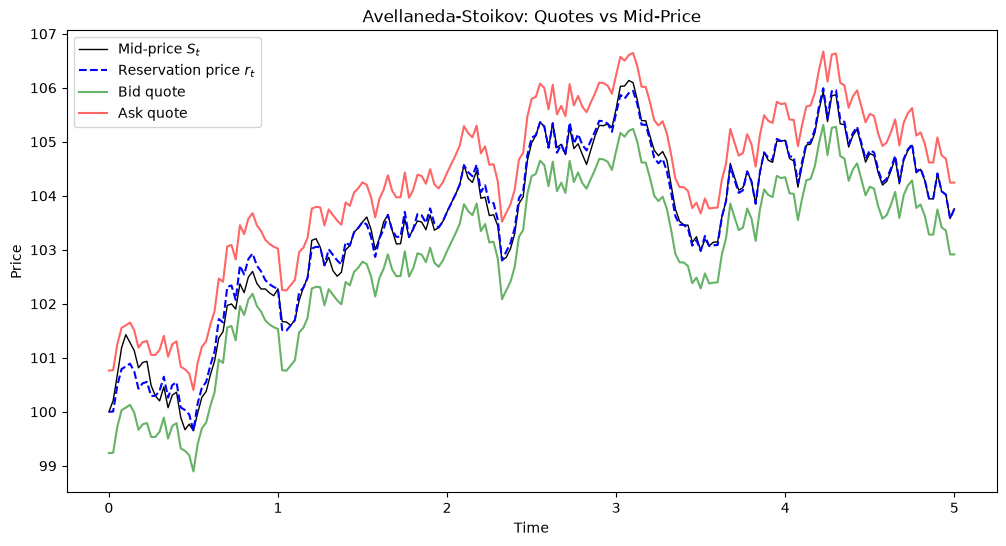

In [29]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(result['t'], result['S'], label='Mid-price $S_t$', color='black', linewidth=1)
ax.plot(result['t'], result['reservation'], label='Reservation price $r_t$', color='blue', linestyle='--')
ax.plot(result['t'], result['bid'], label='Bid quote', color='green', alpha=0.6)
ax.plot(result['t'], result['ask'], label='Ask quote', color='red', alpha=0.6)

ax.set_xlabel('Time')
ax.set_ylabel('Price')
ax.set_title('Avellaneda-Stoikov: Quotes vs Mid-Price')
ax.legend()
plt.show()

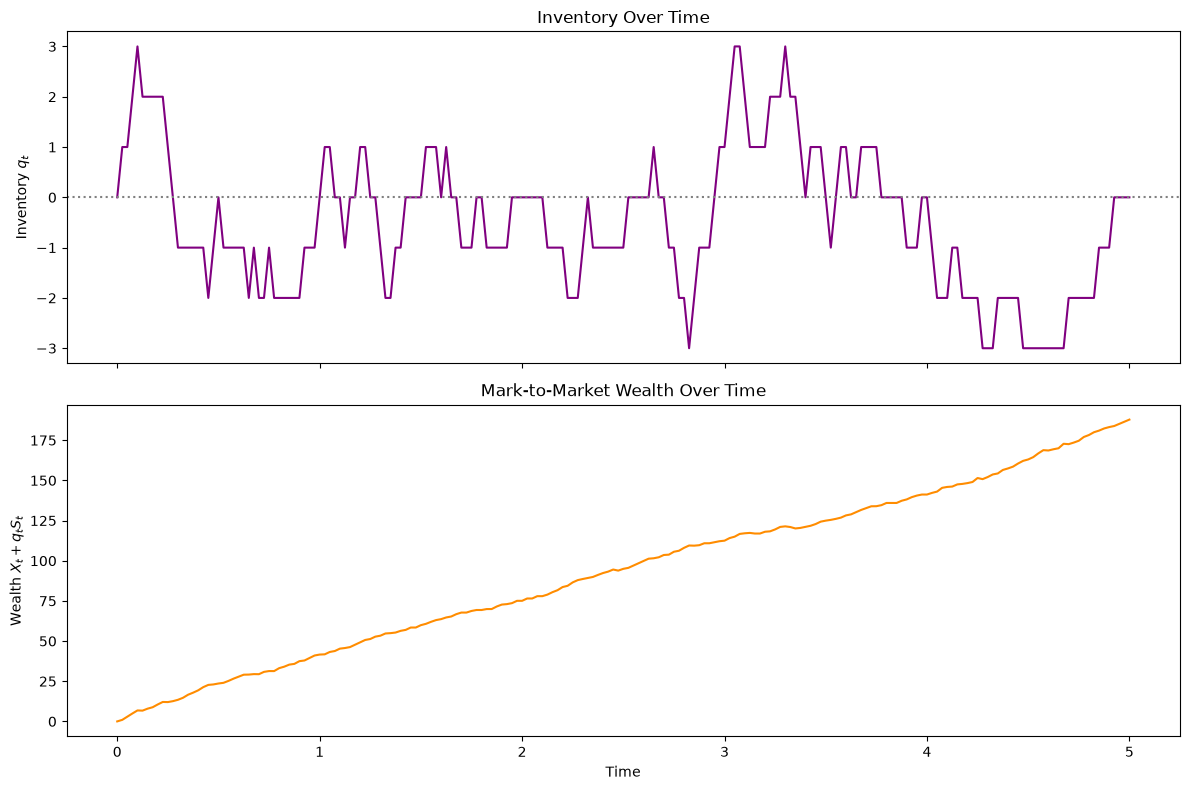

In [30]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(result['t'], result['q'], color='purple')
axes[0].axhline(0, color='gray', linestyle=':')
axes[0].set_ylabel('Inventory $q_t$')
axes[0].set_title('Inventory Over Time')

axes[1].plot(result['t'], result['wealth'], color='darkorange')
axes[1].set_ylabel('Wealth $X_t + q_t S_t$')
axes[1].set_xlabel('Time')
axes[1].set_title('Mark-to-Market Wealth Over Time')

plt.tight_layout()
plt.show()

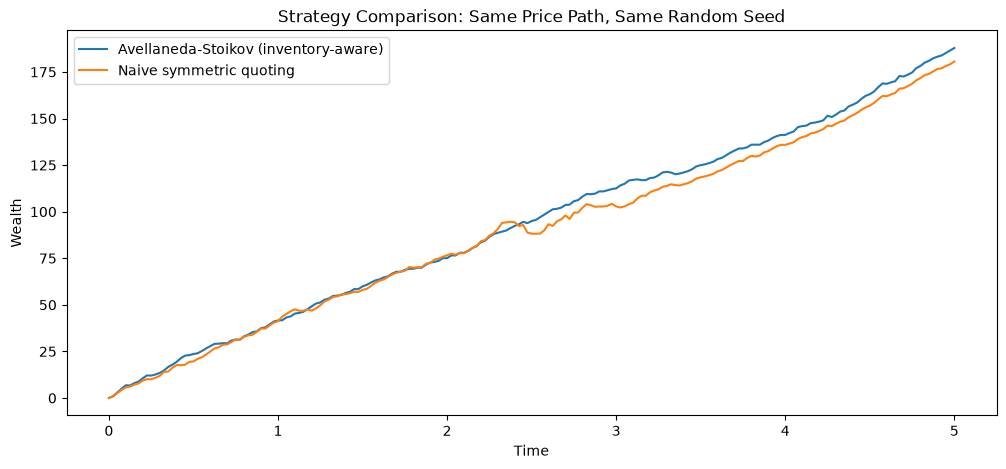

In [31]:
def simulate_naive_mm(S0, sigma, T, gamma, k, A, n_steps, seed=None):
    """Same setup, but always quotes symmetrically around mid (no reservation-price skew)."""
    if seed is not None:
        np.random.seed(seed)

    dt = T / n_steps
    times = np.linspace(0, T, n_steps + 1)

    S = np.zeros(n_steps + 1); q = np.zeros(n_steps + 1); x = np.zeros(n_steps + 1)
    S[0] = S0
    fixed_half_spread = (1 / gamma) * np.log(1 + gamma / k)  # no inventory term at all

    for i in range(n_steps):
        bid = S[i] - fixed_half_spread
        ask = S[i] + fixed_half_spread

        lambda_b = A * np.exp(-k * fixed_half_spread)
        lambda_a = A * np.exp(-k * fixed_half_spread)

        if np.random.rand() < 1 - np.exp(-lambda_b * dt):
            q[i+1] = q[i] + 1; x[i+1] = x[i] - bid
        else:
            q[i+1] = q[i]; x[i+1] = x[i]
        if np.random.rand() < 1 - np.exp(-lambda_a * dt):
            q[i+1] -= 1; x[i+1] += ask

        S[i+1] = S[i] + sigma * np.sqrt(dt) * np.random.randn()

    return {"t": times, "S": S, "q": q, "x": x, "wealth": x + q * S}

naive = simulate_naive_mm(S0, sigma, T, gamma, k, A, n_steps, seed=42)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(result['t'], result['wealth'], label='Avellaneda-Stoikov (inventory-aware)')
ax.plot(naive['t'], naive['wealth'], label='Naive symmetric quoting')
ax.set_xlabel('Time'); ax.set_ylabel('Wealth')
ax.set_title('Strategy Comparison: Same Price Path, Same Random Seed')
ax.legend()
plt.show()

Avellaneda-Stoikov:
  Mean PnL: 194.608, Std: 10.161, Sharpe-like: 19.153

Naive symmetric:
  Mean PnL: 190.723, Std: 28.778, Sharpe-like: 6.627


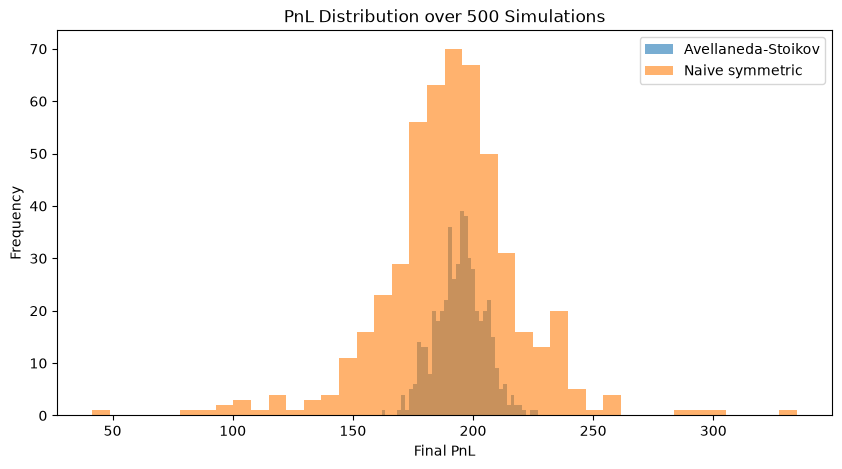

In [32]:
n_sims = 500
final_wealth_as = np.zeros(n_sims)
final_wealth_naive = np.zeros(n_sims)

for i in range(n_sims):
    r_as = simulate_market_maker(S0, sigma, T, gamma, k, A, n_steps, seed=i)
    r_naive = simulate_naive_mm(S0, sigma, T, gamma, k, A, n_steps, seed=i)
    final_wealth_as[i] = r_as['wealth'][-1]
    final_wealth_naive[i] = r_naive['wealth'][-1]

print("Avellaneda-Stoikov:")
print(f"  Mean PnL: {final_wealth_as.mean():.3f}, Std: {final_wealth_as.std():.3f}, Sharpe-like: {final_wealth_as.mean()/final_wealth_as.std():.3f}")
print("\nNaive symmetric:")
print(f"  Mean PnL: {final_wealth_naive.mean():.3f}, Std: {final_wealth_naive.std():.3f}, Sharpe-like: {final_wealth_naive.mean()/final_wealth_naive.std():.3f}")

plt.figure(figsize=(10, 5))
plt.hist(final_wealth_as, bins=40, alpha=0.6, label='Avellaneda-Stoikov')
plt.hist(final_wealth_naive, bins=40, alpha=0.6, label='Naive symmetric')
plt.xlabel('Final PnL'); plt.ylabel('Frequency')
plt.title(f'PnL Distribution over {n_sims} Simulations')
plt.legend()
plt.show()